# Settings

### Autoreload of ipynb

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
!pip install gdown

In [3]:
#collapse-output
import gdown

url = 'https://drive.google.com/file/d/1INNxs9hiuKFrAqtWtxPd4xcMfU2cF9Uo/view?usp=sharing'
output_path = './'
gdown.download(url, output_path, quiet=False,fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1INNxs9hiuKFrAqtWtxPd4xcMfU2cF9Uo
From (redirected): https://drive.google.com/uc?id=1INNxs9hiuKFrAqtWtxPd4xcMfU2cF9Uo&confirm=t&uuid=da103624-6ea6-4f7a-9635-b1581398038f
To: /content/CNRL-CC-GPU.zip
100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]


'./CNRL-CC-GPU.zip'

In [4]:
!unzip CNRL-CC-GPU.zip

Archive:  CNRL-CC-GPU.zip
   creating: CNRL-CC-FAST/build/
 extracting: CNRL-CC-FAST/build/README.md  
   creating: CNRL-CC-FAST/dep/
 extracting: CNRL-CC-FAST/dep/README.md  
   creating: CNRL-CC-FAST/doc/
 extracting: CNRL-CC-FAST/doc/README.md  
  inflating: CNRL-CC-FAST/LICENSE    
  inflating: CNRL-CC-FAST/README.md  
 extracting: CNRL-CC-FAST/requirements.txt  
   creating: CNRL-CC-FAST/res/
  inflating: CNRL-CC-FAST/res/Dopamine_New_1.png  
   creating: CNRL-CC-FAST/res/CC/
  inflating: CNRL-CC-FAST/res/CC_Dopamine.png  
  inflating: CNRL-CC-FAST/res/Decision.png  
 extracting: CNRL-CC-FAST/res/README.md  
  inflating: CNRL-CC-FAST/res/Decision2.png  
  inflating: CNRL-CC-FAST/res/Decision_New_1.png  
   creating: CNRL-CC-FAST/res/FC/
  inflating: CNRL-CC-FAST/res/FC/FC_K5_N50.png  
   creating: CNRL-CC-FAST/samples/
  inflating: CNRL-CC-FAST/samples/Classifier_Acc_Test.ipynb  
  inflating: CNRL-CC-FAST/samples/L5-6.ipynb  
 extracting: CNRL-CC-FAST/samples/README.md  
  inflati

### Changing the path to the main directories path

In [5]:
import os
os.chdir(r"/content/CNRL-CC-FAST/src")
os.getcwd()

'/content/CNRL-CC-FAST/src'

In [6]:
!pip install pymonntorch cnrl-conex pyinstrument

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.4/144.4 kB 14.2 MB/s eta 0:00:00


# Imports

In [7]:
from conex import *
from pymonntorch import *

from matplotlib import pyplot as plt
from PIL import Image

import torchvision
from torch.utils.data import DataLoader

from conex.helpers.filters import DoGFilter

from L423.tools.visualize import *
from L56.RefrenceFrames import RefrenceFrame
from L56.stimuli.current_base import RandomInputCurrent
from L56.synapse.vDistributor import ManualVCoder
from InputLayer.DataLoaderLayer import DataLoaderLayer
from InputLayer.synapse.LocationCoder import LocationCoder
from L423.network.SetTarget import SetTarget
from L423.L423 import L4, L23
from FC import fullyConnected
from FC.synapse.learning import AttentionBasedRSTDP
from FC.tools.model_evaluation import accuracy_score

from L56.tools.visualization import refrence_frame_raster
from L423.tools.visualize import show_filters

from torchvision.datasets import MNIST

In [8]:
import pyinstrument

# Configs

In [9]:
REFRENCE_FRAME_DIM = 23
REFRENCE_INH_DIM = 15
SCREEN_SHOT_PATH = "C:\\Users\\amilion\\Desktop\\develop\\python\\NS\\records\\L5.6"

Input_Width = 28
Input_Height = 28
Crop_Window_Width = 23
Crop_Window_Height = 23
DoG_SIZE = 5

IMAGE_WIDTH = 28
IMAGE_HEIGHT = 28
IMAGE_NUMBER = 100

OUT_CHANNEL = 160
IN_CHANNEL = 1
KERNEL_WIDTH = 13
KERNEL_HEIGHT = 13

DATASET_IMAGE_WIDTH = IMAGE_WIDTH - DoG_SIZE + 1
DATASET_IMAGE_HEIGHT = IMAGE_HEIGHT - DoG_SIZE + 1
INPUT_WIDTH = Crop_Window_Width - DoG_SIZE + 1
INPUT_HEIGHT = Crop_Window_Height - DoG_SIZE + 1

L4_WIDTH = Crop_Window_Width - KERNEL_WIDTH + 1
L4_HEIGHT = Crop_Window_Height - KERNEL_HEIGHT + 1

L23_WIDTH = L4_WIDTH//2
L23_HEIGHT = L4_HEIGHT//2

J_0 = 300
p = 0.8

TRAIN_IMAGES_NUMBER = 10
TEST_IMAGES_NUMBER = 4
TRAIN_ITERATIONS = 10*10*200
REST_INTERVAL = 100
TEST_ITERATIONS = 10*4*200

SACCADE = 3

DEVICE = "cuda"
DTYPE = torch.float32

# Loading Data

In [10]:
a = [1, 2, 3]
torch.Tensor(a)

tensor([1., 2., 3.])

In [11]:
MNIST_ROOT = "./MNIST"

time_window = 100
crop_iteration = 3

dataset_directory_path = "./first_step"

transformation = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Grayscale(num_output_channels = 1), # not necessary
    Conv2dFilter(DoGFilter(size = 5, sigma_1 = 4, sigma_2 = 1, zero_mean=True, one_sum=True).unsqueeze(0).unsqueeze(0)), # type: ignore
    SqueezeTransform(dim = 0), # type: ignore
])


dataset = MNIST(root=MNIST_ROOT, train=True, download=True, transform=transformation)

classes = torch.Tensor([])
for i in range(10) :
    i_class = dataset.data[dataset.targets == i][:TRAIN_IMAGES_NUMBER + TEST_IMAGES_NUMBER]
    print(i_class.shape)
    classes = torch.cat((classes, i_class), dim = 0)

print(classes.shape)

target = []
for i in range(10) :
    target += [i] * (TRAIN_IMAGES_NUMBER + TEST_IMAGES_NUMBER)
target = torch.Tensor(target)

new_dataset_size = classes.shape[0]

t = torch.arange(new_dataset_size)
np.random.shuffle(t.numpy())
two_class_dataset = classes[t]
target = target[t]

new_dataset = torch.empty(0, DATASET_IMAGE_WIDTH, DATASET_IMAGE_WIDTH)
centers = []

for i in range(0, new_dataset_size):
    img = two_class_dataset[i]  # 4 in range [0, 5842) ; 9 in range [5842, 11791)
    img = Image.fromarray(img.numpy(), mode="L")
    img = transformation(img)
    # import pdb;pdb.set_trace()
    new_dataset = torch.cat((new_dataset.data, img.data.view(1, *img.data.shape)), dim=0)

new_dataset.to(DEVICE)
dl = DataLoader(new_dataset,shuffle=False)

torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([14, 28, 28])
torch.Size([140, 28, 28])


# Initialize Network

In [12]:
net = Neocortex(
    dt = 1,
    dtype= DTYPE,
    device= DEVICE,
    behavior = {5 : SetTarget(target = target), 601 : Recorder(["dopamine"], device = DEVICE),},
    index=True
)

## L56

In [13]:
# L56 = RefrenceFrame(
#     net=net,
#     k=10,
#     refrence_frame_side=REFRENCE_FRAME_DIM,
#     inhibitory_size=REFRENCE_INH_DIM,
#     competize=True
# )

## L4

In [14]:
L4 = L4(
    net = net,
    IN_CHANNEL = IN_CHANNEL,
    OUT_CHANNEL = OUT_CHANNEL,
    HEIGHT = L4_HEIGHT,
    WIDTH = L4_WIDTH,
    INH_SIZE = 7
)

# L23

In [15]:
L23 = L23(
    net = net,
    IN_CHANNEL = IN_CHANNEL,
    OUT_CHANNEL = OUT_CHANNEL,
    HEIGHT = L23_HEIGHT,
    WIDTH = L23_WIDTH
)

## InputLayer

In [16]:
input_layer = DataLoaderLayer(
    net=net,
    data_loader=dl,
    targets=target,
    widnow_size=Crop_Window_Height,
    saccades_on_each_image=SACCADE,
    rest_interval=50,
    train_iterations=TRAIN_ITERATIONS,
    phase_interval=REST_INTERVAL,
    test_iterations=TEST_ITERATIONS,
    train_images_number=TRAIN_IMAGES_NUMBER,
    test_images_number=TEST_IMAGES_NUMBER
).build_data_loader()

## FullyConncted

In [17]:
fclayer = fullyConnected.FC(
    net = net,
    N = 100,
    K = 10
)

# Synapsis

### Without Learning

In [18]:
Synapsis_L4_L23 = Synapsis(
    net = net,
    src = L4.layer,
    dst = L23.layer,
    input_port="output",
    output_port="input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),
        AveragePool2D(current_coef = 50000),
    ]),
    synaptic_tag="Proximal"
)


# Synapsis_Inp_L56 = Synapsis(
#     net = net,
#     src = input_layer,
#     dst = L56.layer,
#     input_port = "data_out",
#     output_port = "input",
#     synapsis_behavior=prioritize_behaviors([
#         SynapseInit(),]) | {
#         275: LocationCoder()
#     },
#     synaptic_tag="Proximal"
# )

# Inp_to_L56 = Synapsis(
#     net = net,
#     src = input_layer,
#     dst = L56.layer,
#     input_port = "data_out",
#     output_port = "input",
#     synapsis_behavior=prioritize_behaviors([
#         SynapseInit(),]) | {
#         275: LocationCoder()
#     },
#     synaptic_tag="Proximal"
# )

### With Learning

In [19]:
class ali(Behavior) :

    def forward(self, synapse) :

        spikes = synapse.src.axon.get_spike(synapse.src, synapse.src_delay)
        print(spikes.device)
        if hasattr(synapse, "weights") :
            print(synapse.weights.device)
        print(synapse.tags)
        print("--------")


In [20]:
Synapsis_Inp_L4 = Synapsis(
    net = net,
    src = input_layer,
    dst = L4.layer,
    input_port="data_out",
    output_port="input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),
        WeightInitializer(weights = torch.normal(0.1, 2, (OUT_CHANNEL, IN_CHANNEL, KERNEL_HEIGHT, KERNEL_WIDTH)).to(DEVICE) ),
        Conv2dDendriticInput(current_coef = 20000 , stride = 1, padding = 0),
        Conv2dSTDP(a_plus=0.8, a_minus=0.001),
        WeightNormalization(norm = 4)
    ]),
    synaptic_tag="Proximal"
)

Synapsis_L23_FC = Synapsis(
    net = net,
    src = L23.layer,
    dst = fclayer.layer,
    input_port="output",
    output_port="input",
    synapsis_behavior=prioritize_behaviors([
        SynapseInit(),
        WeightInitializer(mode = "random"),
        SimpleDendriticInput(current_coef = 100),
        WeightNormalization(norm = 35),
        WeightClip(w_min = 0, w_max = 1.65)
    ]) | ({
        400 : AttentionBasedRSTDP(a_plus = 0.008 , a_minus = 0.001, tau_c = 6, attention_plus = 1, attention_minus = 0, number_of_classes = 2),
        # 7 : ali(),
        # 179 : ali(),
        # 210 : ali(),
        # 345 : ali(),
    }),
    synaptic_tag="Proximal"
)

# L23_to_L56 = Synapsis(
#     net=net,
#     src=L23.layer,
#     dst=L56.layer,
#     input_port="output",
#     output_port="input",
#     synaptic_tag="Apical, exi",
#     synapsis_behavior=prioritize_behaviors(
#         [
#             SynapseInit(),
#             SimpleDendriticInput(),
#             WeightInitializer(mode="normal(0.05, 0.01)"),
#             SimpleSTDP(w_min=0, w_max=100, a_plus=1, a_minus=0.0008)
#         ]
#     )
# )

# L56_to_L23 = Synapsis(
#     net=net,
#     src=L56.layer,
#     dst=L23.layer,
#     input_port="output",
#     output_port="input",
#     synaptic_tag="Apical, exi",
#     synapsis_behavior=prioritize_behaviors(
#         [
#             SynapseInit(),
#             SimpleDendriticInput(),
#             WeightInitializer(mode="normal(0.05, 0.01)"),
#             SimpleSTDP(w_min=0, w_max=10, a_plus=1, a_minus=0.0008)
#         ]
#     )
# )

# Simulate Network

In [21]:
# for syn in net.SynapseGroups :
#     syn.add_behavior(7, ali(), initialize = False)
#     syn.add_behavior(179, ali(), initialize = False)
#     syn.add_behavior(210, ali(), initialize = False)
#     syn.add_behavior(345, ali(), initialize = False)

In [22]:
net.initialize()
net.simulate_iterations(TRAIN_ITERATIONS)

Streaming output truncated to the last 5000 lines.
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'NeuronGroup_5 => NeuronGroup_1', 'Conv2dDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'NeuronGroup_3 => target', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'NeuronGroup_1 => inh', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'inh => NeuronGroup_1', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'NeuronGroup_1 => NeuronGroup_1', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'inh => inh', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'NeuronGroup_3 => inh', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'inh => NeuronGroup_3', 'SimpleDendriticInput']
--------
cuda:0
cuda:0
['Proximal', 'SynapseGroup', 'syn', 'inh => inh', 'SimpleDendriticInput']

KeyboardInterrupt: 

# Visualization

## Filters

In [ ]:
show_filters(Synapsis_Inp_L4.synapses[0].weights)

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(net["dopamine", 0])
plt.show()

# Rest Interval

In [ ]:
net.simulate_iterations(REST_INTERVAL)

# Test Section

### Clearing learnings

In [ ]:
Synapsis_Inp_L4.remove_behavior(400)
Synapsis_L23_FC.remove_behavior(400)
# L23_to_L56.remove_behavior(400)
# L56_to_L23.remove_behavior(400)

### Running Network

In [ ]:
net.simulate_iterations(TEST_ITERATIONS)
net["targets"]

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(net["dopamine", 0])
plt.show()

## Accuracy Score

In [ ]:
print("Test Accuracy :", accuracy_score(
    fclayer.E_NG_GROUP,
    K = 2,
    window_size = TEST_ITERATIONS // TEST_IMAGES_NUMBER,
    targets=net["targets"][0],
    dataset_size = TEST_IMAGES_NUMBER,
    offset=TRAIN_ITERATIONS + REST_INTERVAL) * 100
)

# Decision-Making Raster Plot

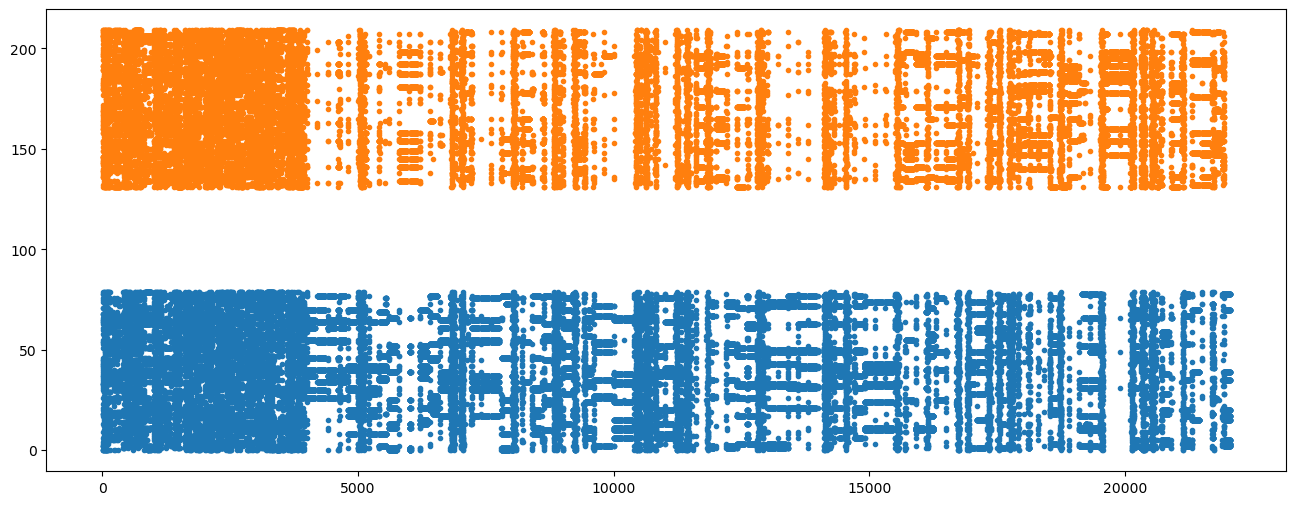

In [ ]:
plt.figure(figsize=(16, 6))
# for i in range(fclayer.K) :
    # a = (i * 1600)
    # b = ((i + 1) * 1600)

acc_list = [92.5, 92.5, 95, 92.5, 100]

plt.plot(fclayer.E_NG_GROUP['spikes.t', 0][fclayer.E_NG_GROUP['spikes', 0][:,1] < 80], fclayer.E_NG_GROUP['spikes.i', 0][fclayer.E_NG_GROUP['spikes', 0][:,1] < 80], '.')
plt.plot(fclayer.E_NG_GROUP['spikes.t', 0][fclayer.E_NG_GROUP['spikes', 0][:,1] > 80], fclayer.E_NG_GROUP['spikes.i', 0][fclayer.E_NG_GROUP['spikes', 0][:,1] > 80] + 50, '.')

# Accuracy List

In [ ]:
acc_list

[92.5, 92.5, 95, 92.5, 100]

## Mean Acc

In [ ]:
acc_list = torch.tensor(acc_list)
acc_list.mean()

tensor(94.5000)